# ISEL - Semestre 2024/25
# <center> Trabalho Prático 2 - CSM </center>

Trabalho realizado por:
* Marta Garcia, número <b> 51564 </b>
* Rui Ferreira, número <b> 51597 </b>
* Matilde Gonçalves, número <b> 51706 </b>

<b> Turma L42D - Docente Gonçalo Valadão</b>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Exercício A

<b>$N$</b> = Número de vezes que a moeda foi atirada <br>
<b>$f_H$</b> = Probabilidade de sair cara <br>
<b>$n_H$</b> = Número de vezes que saiu cara em <b>$N$</b> lançamentos <br>

$$ P({f_{H}}_{N+1} \space ser \space cara)

Combination = $\frac{N!}{n_H! (N-n_H)!}$ <br>
<br>
Binomial = $\binom{N}{n_H} f_H^{n_H}(1-f_H)^{N-n_H}$

In [2]:
def combination(N, nH):
    """
    Função utilizada para calcular o número de combinações possíveis de N lançamentos, escolhendo nH para serem caras.

    Args:
        N (int): Número total de lançamentos da moeda.
        nH (int): Número de vezes que saiu cara.

    Returns:
        float: Número de combinações possíveis (coeficiente binomial).
    """
    return fatorial(N)/(fatorial(nH)*fatorial(N-nH))

def binomial(N, nH, fH):
    """
    Função responsável por calcular a probabilidade de obter nH caras em N lançamentos de uma moeda viciada,
    assumindo a probabilidade fH de sair cara em cada lançamento.

    Args:
        N (int): Número total de lançamentos da moeda.
        nH (int): Número de vezes que saiu cara.
        fH (float): Probabilidade de sair cara em cada lançamento.

    Returns:
        float: Probabilidade de observar nH caras em N lançamentos.
    """
    return combination(N, nH)*(fH**nH)*((1-fH)**(N-nH))

def fatorial(n):
    """
    Função auxiliar para calcular o fatorial de um número inteiro n.

    Args:
        n (int): Número inteiro não negativo.

    Returns:
        aux (int): Representa o fatorial de n.
    """
    aux = 1
    for i in range(n):
        aux *= i + 1
    return aux

In [3]:
def post_distr(N, nH, fH):
    """
    Função que calcula a distribuição posterior da probabilidade de sair cara (fH) após observar nH caras em N lançamentos,
    assumindo um prior uniforme para fH.

    Args:
        N (int): Número total de lançamentos da moeda.
        nH (int): Número de vezes que saiu cara.
        fH (np.ndarray): Vetor de valores possíveis para a probabilidade de sair cara.

    Returns:
        np.ndarray: Contém os valores da função de verosimilhança para cada valor de fH.
    """
    maximo = N + 1
    n = maximo - (N - nH)
    aux = 1
    for i in range(n):
        aux *= maximo
        maximo -= 1
    
    return (aux * np.power(fH, nH) * np.power((1 - fH), (N-nH))) / fatorial(nH)

def prob_next_N(N, nH):
    """
    Calcula a probabilidade de o próximo lançamento (N+1) ser cara,
    dado que se observaram nH caras em N lançamentos, assumindo um prior uniforme para fH.

    Usa a regra da soma para obter a média da distribuição posterior de fH.

    Args:
        N (int): Número total de lançamentos da moeda.
        nH (int): Número de vezes que saiu cara.

    Returns:
        float: Probabilidade de o lançamento N+1 ser cara.
    """
    return (fatorial(nH + 1)) / (fatorial(nH) * (N + 2))

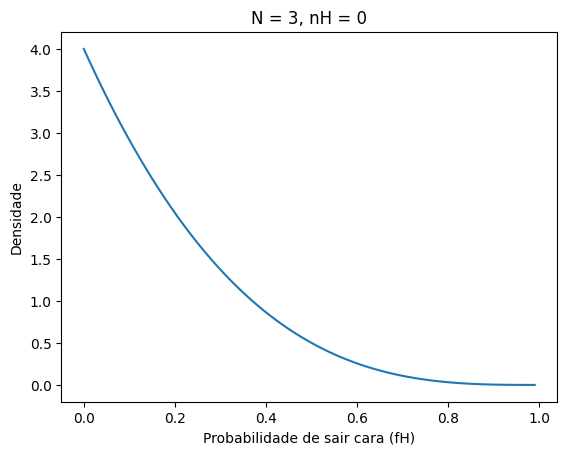

P(N+1 ser cara) = 0.2


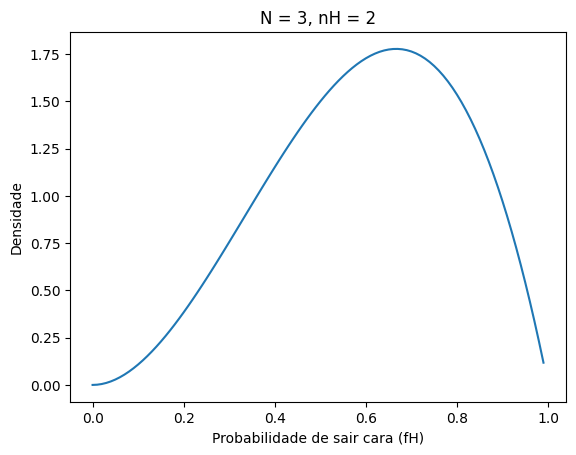

P(N+1 ser cara) = 0.6


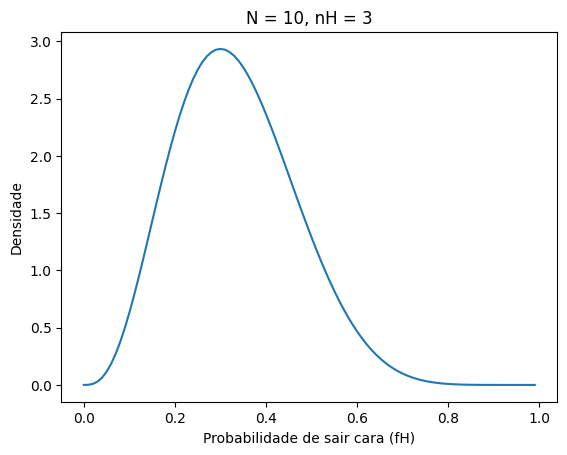

P(N+1 ser cara) = 0.3333333333333333


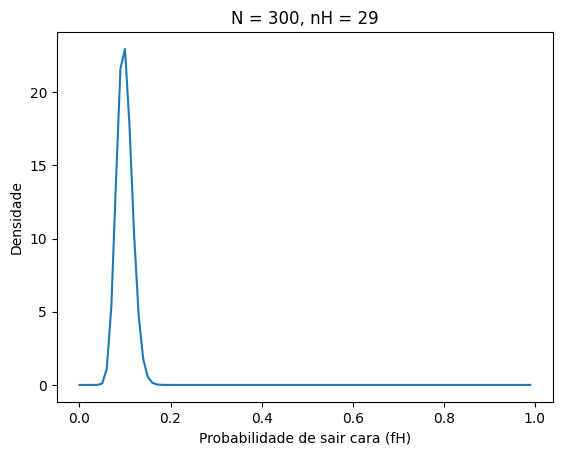

P(N+1 ser cara) = 0.09933774834437085


In [4]:
N = [3, 3, 10, 300]
nH = [0, 2, 3, 29]
fH = np.arange(0, 1, 0.01)

for i in range(4):
    y = post_distr(N[i], nH[i], fH)
    plt.plot(fH, y)
    plt.title(f"N = {N[i]}, nH = {nH[i]}")
    plt.xlabel('Probabilidade de sair cara (fH)')
    plt.ylabel('Densidade')
    plt.show()
    print("P(N+1 ser cara) = " + str(prob_next_N(N[i], nH[i])))

# Exercício B

In [5]:
prob_A = 0.4
prob_B = 0.35
prob_C = 0.25

## (a)

In [6]:
P_algoritmo = np.zeros(3)

P_algoritmo[0] = prob_A
P_algoritmo[1] = prob_B
P_algoritmo[2] = prob_C

P_NC_dado_algoritmo = [[0.05, 0.10, 0.20], 
                       [0.15, 0.20, 0.25], 
                       [0.40, 0.40, 0.30], 
                       [0.30, 0.20, 0.15], 
                       [0.10, 0.10, 0.10]]

P_conjunta = np.zeros((5, 3)) # P_conjunta com as dimensões de P_NC_dado_algoritmo
for i in range(5):
    for j in range(3):
        # Calculo da distribuição conjunta (P_conjunta) multiplicando as probabilidades à priori pela verosimilhança.
        P_conjunta[i][j] = P_NC_dado_algoritmo[i][j] * P_algoritmo[j]
        
print(P_conjunta)

P_marginal = np.zeros(5) 
for i in range(5):
    for j in range(3):
        # Calculo da distribuição marginal dos níveis de compressão (P_marginal) somando as probabilidades conjuntas para cada NC.
        P_marginal[i] += P_conjunta[i][j]
        
print(f"\nP_marginal = {P_marginal}")
print(f"Soma = {P_marginal.sum().round(2)}")

[[0.02   0.035  0.05  ]
 [0.06   0.07   0.0625]
 [0.16   0.14   0.075 ]
 [0.12   0.07   0.0375]
 [0.04   0.035  0.025 ]]

P_marginal = [0.105  0.1925 0.375  0.2275 0.1   ]
Soma = 1.0


## (b)

In [7]:
def classifica_algoritmo(NC):
    """
    Função responsável por calcular a distribuição de probabilidades à posteriori de cada algoritmo de compressão,
    dado um nível de compressão observado (NC).

    Esta função aplica a regra de Bayes para determinar P(algoritmo | NC), ou seja,
    a probabilidade de cada algoritmo ter sido utilizado, sabendo que o nível de compressão observado foi NC.

    Args:
        NC (int): Nível de compressão observado (valor entre 0 e 4).

    Returns:
        result (np.ndarray): Contém as probabilidades à posteriori de cada algoritmo (A, B, C) para o NC observado.
    """
    result = np.zeros(3)
    for i in range(3):
        result[i] = P_conjunta[NC][i] / P_marginal[NC]
    return result

print(f"Classifica_algoritmo(NC = 3) = {classifica_algoritmo(3).round(3)}")
print(f"Soma = {classifica_algoritmo(3).sum().round(2)}")

Classifica_algoritmo(NC = 3) = [0.527 0.308 0.165]
Soma = 1.0


## (c)

In [8]:
#Função que identifica qual o valor de nível de compressão que maximiza a verosimilhança
#j - índice do algoritmo
def max_verosimil(j):
    max = 0 #Variável que vai armazenar o maior valor de verosimilhança
    indice = 0 #Variável que vai armazenar o índice que corresponde ao maior valor de verosimilhança
    for i in range(5):
        if P_NC_dado_algoritmo[i][j] > max: #Verificar se o valor atual é maior do que o máximo guardado
            max = P_NC_dado_algoritmo[i][j] 
            indice = i
    return indice

print(f'Nível de compressão mais verosímil de A = {max_verosimil(0)}')
print(f'Nível de compressão mais verosímil de B = {max_verosimil(1)}')
print(f'Nível de compressão mais verosímil de C = {max_verosimil(2)}')

#Função que identifica qual o algoritmo mais provável para cada nível de compressão, 
#ou seja, o algoritmo que maximiza a probabilidade posteriori para cada nível de compressão.
#j - índice do algoritmo
def max_posteriori(i):
    max = 0 #Variável que vai armazenar o maior valor da probabilidade posteriori
    indice = 0 #Variável que vai armazenar o índice que corresponde ao maior valor da probabilidade posteriori
    for j in range(3):
        if P_NC_dado_algoritmo[i][j] > max:  #Verificar se o valor atual é maior do que o máximo guardado
            max = P_NC_dado_algoritmo[i][j]
            indice = j
    #Retornar o caracter correspondente ao algoritmo mais provável
    if indice == 0:
        return "A"
    elif indice == 1:  
        return "B"
    elif indice == 2:
        return "C" 

print(f'Algoritmo mais provável para NC=0 = {max_posteriori(0)}')
print(f'Algoritmo mais provável para NC=1 = {max_posteriori(1)}')
print(f'Algoritmo mais provável para NC=2 = {max_posteriori(2)}')
print(f'Algoritmo mais provável para NC=3 = {max_posteriori(3)}')
print(f'Algoritmo mais provável para NC=4 = {max_posteriori(4)}')

Nível de compressão mais verosímil de A = 2
Nível de compressão mais verosímil de B = 2
Nível de compressão mais verosímil de C = 2
Algoritmo mais provável para NC=0 = C
Algoritmo mais provável para NC=1 = C
Algoritmo mais provável para NC=2 = A
Algoritmo mais provável para NC=3 = A
Algoritmo mais provável para NC=4 = A


## (d)

Valor esperado dado por: $ E[X] = \space \sum_{i} x_i f_X (x_i)$

No nosso caso, $ E[NC] = \sum_{i=0}^{4} NC_i \times P(NC_i | \text{Algoritmo}) $

In [9]:
NC = np.array([0, 1, 2, 3, 4])
P_NC_algoritmo = np.array(P_NC_dado_algoritmo)

In [10]:
def valor_esperado():
    """
    Função que calcula o valor esperado do número de NC para cada algoritmo.

    Returns:
        v_esperado (np.ndarray): Contém o valor esperado de NC para cada algoritmo (A, B e C).
    """
    v_esperado = np.dot(NC, P_NC_algoritmo)
    return v_esperado

v_esperado = valor_esperado()
print(f"Valor esperado para o algoritmo A: {v_esperado[0]:.2f}")
print(f"Valor esperado para o algoritmo B: {v_esperado[1]:.2f}")
print(f"Valor esperado para o algoritmo C: {v_esperado[2]:.2f}")

Valor esperado para o algoritmo A: 2.25
Valor esperado para o algoritmo B: 2.00
Valor esperado para o algoritmo C: 1.70


Variância dada por: $ \space Var[X] \space = \space E[X^2] - E[X]^2, \space onde \space E[X^2] \space = \sum_{i} x_i^2 f_X (x_i), \space ou \space seja, \space E[NC^2] = \sum_{i=0}^{4} NC_i^2 \times P(NC_i | \text{Algoritmo}) $

In [11]:
def variancia():
    """
    Função que calcula a variância de NC para cada algoritmo.

    Returns:
        var (np.ndarray): Contém o valor da variância de NC para cada algoritmo (A, B e C).
    """
    v_esperado2 = np.dot(NC**2, P_NC_algoritmo) # E[X^2]
    var = v_esperado2 - valor_esperado()**2 # Var[X] = E[X^2] - (E[X])^2
    return var

var = variancia()
print(f"Variância para o algoritmo A: {var[0]:.4f}")
print(f"Variância para o algoritmo B: {var[1]:.4f}")
print(f"Variância para o algoritmo C: {var[2]:.4f}")

Variância para o algoritmo A: 0.9875
Variância para o algoritmo B: 1.2000
Variância para o algoritmo C: 1.5100


## (e)

$P_{empírico} = \frac{\text{número de ocorrências favoráveis}}{\text{número total de ensaios}}$

O número de ocorrências favoráveis corresponde ao número de vezes que o algoritmo foi escolhido para $NC = 2$ e o número total de ensaios corresponde ao número total de vezes que $NC = 2$ ocorreu no número total de amostras (50000).

In [12]:
n_amostras = 50000
algoritmos = np.array([0, 1, 2]) # A, B e C

# O uso do assert garante que as probabilidades somam 1.
assert np.allclose(np.sum(P_algoritmo), 1.0)
assert np.allclose(np.sum(P_NC_algoritmo, axis = 0), 1.0)

# Aleatoriadade segundo o prior
# Gera n_amostras (50 000) escolhas aleatórias do algoritmo (A, B ou C), de acordo com as probabilidades à priori (P_algoritmo).
algoritmo_aleat = np.random.choice(algoritmos, n_amostras, p = P_algoritmo)

# Aleatoriadade segundo a verosimilhança P(NC|Algoritmo)
# Para cada amostra (cada algoritmo escolhido), sorteia um valor de NC de acordo com a distribuição condicional (P(NC|Algoritmo)).
NC_aleat = np.zeros(n_amostras, dtype = int)
for i, alg in enumerate(algoritmo_aleat):
    NC_aleat[i] = np.random.choice(NC, p = P_NC_algoritmo[:, alg])

# Array booleano que indica quais das amostras têm NC = 2.
NC_empirica = (NC_aleat == 2)
# O bincount é utilizado para contar quantas vezes cada algoritmo foi escolhido apenas nos casos em que NC = 2.
# minlength define a quantidade de algoritmos que temos, no caso 3.
estimativa_emp = np.bincount(algoritmo_aleat[NC_empirica], minlength = 3)
P_empirico = estimativa_emp / NC_empirica.sum()

print("Estimativa empírica P(algoritmo|NC=2):")
print(f"A: {P_empirico[0]:.4f}, B: {P_empirico[1]:.4f}, C: {P_empirico[2]:.4f}")
print(f"Soma P_empirico = {P_empirico.sum().round(2)}")

# Comparação com o valor teórico
P_teorico = classifica_algoritmo(2)
print("\nValor teórico P(algoritmo|NC=2):")
print(f"A: {P_teorico[0]:.4f}, B: {P_teorico[1]:.4f}, C: {P_teorico[2]:.4f}")
print(f"Soma P_teorico = {P_teorico.sum().round(2)}")

Estimativa empírica P(algoritmo|NC=2):
A: 0.4293, B: 0.3720, C: 0.1987
Soma P_empirico = 1.0

Valor teórico P(algoritmo|NC=2):
A: 0.4267, B: 0.3733, C: 0.2000
Soma P_teorico = 1.0


# Exercício C

## (a)

C:\Users\mdgon\AppData\Local\Temp\ipykernel_5580\2331600683.py:49: RuntimeWarning: divide by zero encountered in log2
  conteudo[g] = np.log2(len(subconjunto))


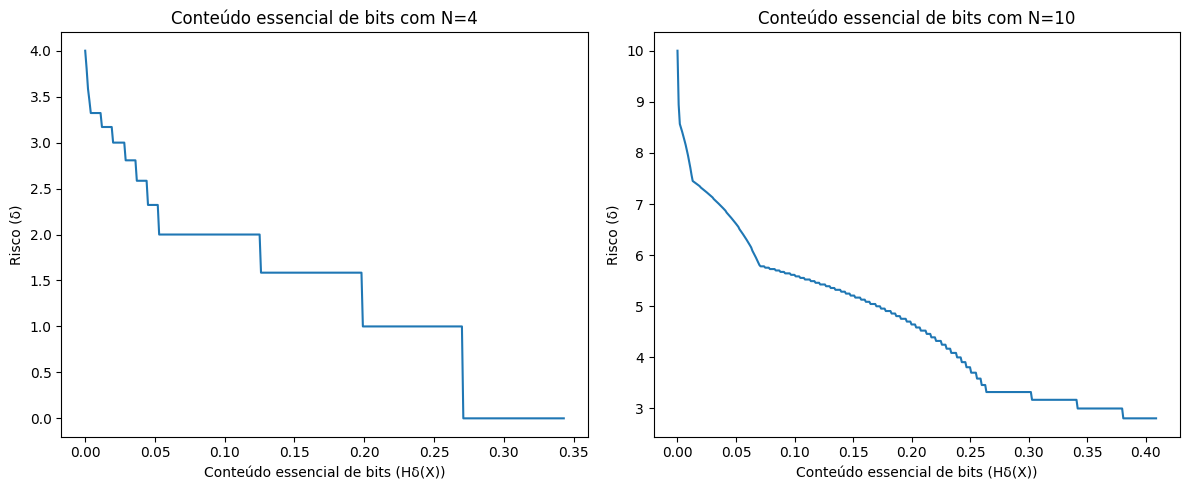

In [13]:
#Função para obter todas as combinações binárias possíveis
#com n bits.
def combinacoes_binarias(n):
    combinacoes = [] #Lista que vai armazenar todas as combinações
    for i in range(2**n): # 2**n - número de combinações que vamos ter 
        array_num = [] #Lista que vai guardar os bits da combinação em questão
        num_binario = format(i, '0' + str(n) + 'b') #Tornar o índice i num número binário de n bits (0nb)
        for j in range(len(num_binario)): #Colocar os bits obtidos na lista 
            array_num.append(int(num_binario[j]))
        combinacoes.append(array_num) #Adicionar á lista com todas as combinações
    return combinacoes

#Função que calcula o conteúdo essencial de bits de um ensemble (Hδ(X)).
#Ax - Lista com alfabeto do ensemble. Contém todos os valores possíveis para a variável aleatória.
#Px - Dicionário que contém as probabilidades para cada valor de xi. 
#gama - Array que contém vários valores de risco (δ).
def conteudo_essencial(Ax, Px, gama):
    #Array que vai armazenar as probabilidades relativas a cada sequência de bits
    probabilidades = np.zeros(len(Ax)) 
    #Calcular as probabilidades relativas a cada sequência de bits
    for seq in range(len(Ax)):
        prob = 1
        for i in range(len(Ax[seq])):
            #Como sucessivos lançamentos de uma moeda são acontecimentos independentes,
            #a probabilidade da sequ~encia vai ser dada pela multiplicação das probabilidades
            #respetivas de cada resultado.
            prob = prob*Px[Ax[seq][i]] 
        #Associar a probabilidade à sequência em questão, colocando-a no mesmo índice da mesma.
        probabilidades[seq] = prob  
    
    probabilidades= np.flip(np.sort(probabilidades)) #Por em ordem decrescente as probabilidades

    #Array que vai conter os valores do conteúdo essencial em bits para cada valor de risco.
    conteudo = np.zeros(len(gama)) 
    for g in range(len(gama)): 
        #Lista que vai conter o mínimo subconjunto δ-suficiente (Sδ) para o risco em questão
        subconjunto = [] 
        soma = 0 
        #O subconjunto vai ser obtido, somando as probabilidades da lista, ordenada por ordem decrescente,
        #que correspondem a cada sequência, até que a probabilidade total seja maior ou igual a (1 − δ).
        #Todas as sequências cuja probabilidade entrou nesta soma, vão fazer parte deste conjunto.
        for i in range(len(probabilidades)):
            soma += probabilidades[i]
            if soma <= (1-gama[g]):
                subconjunto.append(probabilidades[i])
            else:
                break
        #Calcular o conteúdo essencial em bits apartir do subconjunto obtido: Hδ(X) = log2|Sδ|.
        conteudo[g] = np.log2(len(subconjunto)) 
    return conteudo        
                
Px = {0: 0.9, 1: 0.1}
gama = np.arange(0, 0.41, 0.001)

fig, graf = plt.subplots(1, 2, figsize=(12, 5))

n = 4
Ax_N4 = combinacoes_binarias(n)
conteudo_N4 = conteudo_essencial(Ax_N4, Px, gama)
graf[0].plot(gama, conteudo_N4)
graf[0].set_xlabel("Conteúdo essencial de bits (Hδ(X))")
graf[0].set_ylabel("Risco (δ)")
graf[0].set_title("Conteúdo essencial de bits com N=4")

n = 10
Ax_N10 = combinacoes_binarias(n)
conteudo_N10 = conteudo_essencial(Ax_N10, Px, gama)
graf[1].plot(gama, conteudo_N10)
graf[1].set_xlabel("Conteúdo essencial de bits (Hδ(X))")
graf[1].set_ylabel("Risco (δ)")
graf[1].set_title("Conteúdo essencial de bits com N=10")

plt.tight_layout()
plt.show()

## (b)